In [561]:
from robot_vlp.config import INTERIM_DATA_DIR, PROCESSED_DATA_DIR, FIGURES_DIR, MODELS_DIR
import pickle
import numpy as np
import keras
import robot_vlp.data.preprocessing as p
import matplotlib.pyplot as plt
import robot_vlp.data_collection.communication as c

from robot_vlp.modeling.rnn import ang_loss_fn

import robot_vlp.data.odometer_path_navigation as pg
import robot_vlp.plots.model_performance_plotting as pp
import robot_vlp.modeling.rnn as rnn

%load_ext autoreload
%autoreload 2

import tensorflow as tf
tf.config.set_visible_devices([], 'GPU')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [644]:
dir = INTERIM_DATA_DIR / 'exp_vive_navigated_paths'

train_files = [
    # 'exp02_high_acc.csv',
    'exp03_high_acc.csv',
    'exp07_high_acc.csv',

    # 'exp02_low_acc.csv',
    'exp03_low_acc.csv',
    'exp07_low_acc.csv',

    'exp04_high_acc.csv',
    'exp04_low_acc.csv',
    'exp05_high_acc.csv',
    'exp05_low_acc.csv',

    ]
valid_files = [    
    'exp02_high_acc.csv',
    'exp02_low_acc.csv',


]

test_files = [
    'exp01_high_acc.csv',
    # 'exp01_low_acc.csv',


]

overlap = 0.99999
window_len = 40




In [645]:
def read_csv_to_train(file_list):
    X_lst = []
    y_lst = []
    m_lst = []

    for filename in file_list:
        file = dir / filename
        df = pd.read_csv(file)
        X_win, y_win, m_win = preprocess_df(df)
        X_lst.append(X_win)
        y_lst.append(y_win)
        m_lst.append(m_win)


    X = np.concatenate(X_lst, axis = 0)
    y = np.concatenate(y_lst, axis = 0)
    m = np.concatenate(m_lst, axis = 0)

    return X, y, m

In [646]:
X_train, y_train, _ = read_csv_to_train(train_files)
X_valid, y_valid, _ = read_csv_to_train(valid_files)

In [ ]:
run_logdir = rnn.get_run_logdir()  
tensorboard_cb = tf.keras.callbacks.TensorBoard(run_logdir)
early_stopping_cb = tf.keras.callbacks.EarlyStopping(monitor = 'val_loss',patience=30, restore_best_weights = True )
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint('exp_vive_nav.weights.h5',save_weights_only = True)

In [690]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)

input = keras.layers.Input(shape=(None, 3))

# LSTM with BatchNormalization
hidden_layer_1 = keras.layers.Bidirectional(
    keras.layers.LSTM(32, return_sequences=True, recurrent_dropout=0.4, recurrent_regularizer=tf.keras.regularizers.l2(0.01))
)(input)
hidden_layer_1 = keras.layers.BatchNormalization()(hidden_layer_1)

hidden_layer_2 = keras.layers.LSTM(128, return_sequences=True, recurrent_dropout=0.4, recurrent_regularizer=tf.keras.regularizers.l2(0.01))(hidden_layer_1)
hidden_layer_2 = keras.layers.BatchNormalization()(hidden_layer_2)

# Adjust dimensions for residual connection
residual_1 = keras.layers.Dense(128, activation='linear')(hidden_layer_1)  # Transform hidden_layer_1 to match 128 units
hidden_layer_2 = keras.layers.Add()([residual_1, hidden_layer_2])

hidden_layer_3 = keras.layers.LSTM(256, return_sequences=True, recurrent_dropout=0.4, recurrent_regularizer=tf.keras.regularizers.l2(0.01))(hidden_layer_2)
hidden_layer_3 = keras.layers.BatchNormalization()(hidden_layer_3)

# Adjust dimensions for residual connection
residual_2 = keras.layers.Dense(256, activation='linear')(hidden_layer_2)  # Transform hidden_layer_2 to match 256 units
hidden_layer_3 = keras.layers.Add()([residual_2, hidden_layer_3])

# Attention Mechanism
attention_layer = keras.layers.Attention()([hidden_layer_3, hidden_layer_3])

# Concatenate attention output with hidden_layer_3 for better feature extraction
concat_layer = keras.layers.Concatenate()([hidden_layer_3, attention_layer])

last_hidden_layer = keras.layers.LSTM(512, return_sequences=False, recurrent_regularizer=tf.keras.regularizers.l2(0.01))(concat_layer)
last_hidden_layer = keras.layers.BatchNormalization()(last_hidden_layer)
last_hidden_layer = keras.layers.Dropout(0.4)(last_hidden_layer)

# Dense layers with BatchNormalization
out1 = keras.layers.Dense(2, name='pos', kernel_regularizer=tf.keras.regularizers.l2(0.01))(last_hidden_layer)

out2 = keras.layers.Dense(2, kernel_regularizer=tf.keras.regularizers.l2(0.01))(last_hidden_layer)
out2 = keras.layers.BatchNormalization()(out2)  # Normalization before heading normalization
out2 = keras.layers.Lambda(lambda x: tf.linalg.l2_normalize(x, axis=1), name='heading')(out2)

# Build model
model = keras.Model(inputs=input, outputs=[out1, out2])

model.compile(
    optimizer=optimizer,
    loss=['mse', ang_loss_fn],
    loss_weights=[1., 1000.],
    metrics={'heading': [tf.keras.metrics.CosineSimilarity()]}
)

# Callbacks
callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
]


In [712]:
from keras.optimizers import Adam
new_learning_rate = 0.00001  
new_optimizer = Adam(learning_rate=new_learning_rate)

model.compile(optimizer=new_optimizer,
    loss = ['mse',keras.losses.CosineSimilarity(axis=1)],
        loss_weights = [10000., 1.],
    )

In [713]:
history = model.fit(
    x = X_train, 
    y = [y_train[:,[0,1]],  p.ang_to_vector(y_train[:,2], unit = 'degrees').numpy()],
    epochs = 10,
    batch_size = 32,
    validation_data = (X_valid, [y_valid[:,[0,1]], p.ang_to_vector(y_valid[:,2], unit = 'degrees').numpy()]), 
    # callbacks = callbacks
    # callbacks = [tensorboard_cb, early_stopping_cb, checkpoint_cb]    
    )

Epoch 1/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 34s 234ms/step - heading_cosine_similarity: 0.8941 - heading_loss: -0.8941 - loss: 16.0792 - pos_loss: 16.5885 - val_heading_cosine_similarity: 0.9773 - val_heading_loss: -0.9778 - val_loss: 5.0283 - val_pos_loss: 5.5508
Epoch 2/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 30s 252ms/step - heading_cosine_similarity: 0.8756 - heading_loss: -0.8756 - loss: 13.7642 - pos_loss: 14.2570 - val_heading_cosine_similarity: 0.9780 - val_heading_loss: -0.9786 - val_loss: 4.9936 - val_pos_loss: 5.5145
Epoch 3/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 30s 251ms/step - heading_cosine_similarity: 0.8916 - heading_loss: -0.8916 - loss: 14.1959 - pos_loss: 14.7056 - val_heading_cosine_similarity: 0.9785 - val_heading_loss: -0.9791 - val_loss: 5.1730 - val_pos_loss: 5.6572
Epoch 4/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 29s 247ms/step - heading_cosine_similarity: 0.8923 - heading_loss: -0.8923 - loss: 13.2030 - pos_loss: 13.7146 - val_heading_cosine_similarity: 0.9768 - val_heading_loss: -0.977

<Axes: >

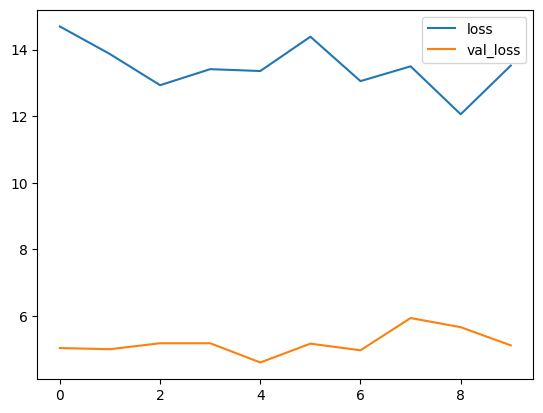

In [714]:
import pandas as pd

pd.DataFrame(history.history)[['loss','val_loss']].plot()

<Axes: >

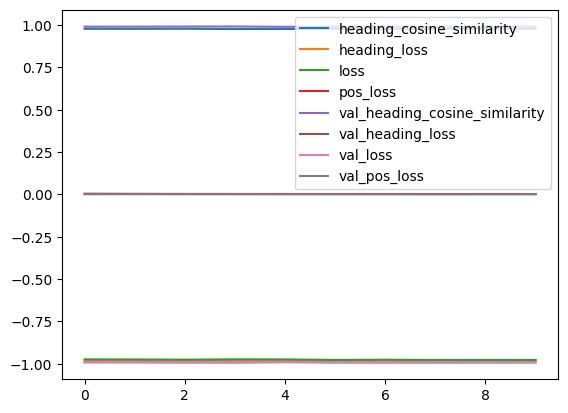

In [678]:
import pandas as pd
pd.DataFrame(history.history).plot()

In [505]:
# model.save(MODELS_DIR / 'exp_vive_trained_position.keras')
model.save(MODELS_DIR / 'exp_vive_trained_heading.keras')

In [660]:
def preprocess_df(df):
    X = df[['vlp_x_hist','vlp_y_hist', 'encoder_heading_change']].values
    y = df[['x_hist', 'y_hist','heading_hist']].values
    X_win, y_win, m_win = p.window_data(X, y, y, overlap = 0.999999, window_len = 40)
    X_win = np.nan_to_num(p.apply_scaler(X_win), 0.5)
    return X_win, y_win, m_win





In [709]:
df = pd.read_csv(dir / 'exp01_high_acc.csv')
X_win, y_win, m_win = preprocess_df(df)
df = df.iloc[39:]
df.reset_index(drop = True, inplace = True)

pre = model.predict(X_win)

df[['model_x_hist', 'model_y_hist']] =  pre[0]
df['model_heading_hist'] = p.vector_to_ang(pre[1], unit = 'degrees')

model_pos_errs = np.sqrt(np.square(df['x_hist'] - df['model_x_hist']) + np.square(df['y_hist'] - df['model_y_hist']))
vlp_pos_errs = np.sqrt(np.square(df['x_hist'] - df['vlp_x_hist']) + np.square(df['y_hist'] - df['vlp_y_hist']))
encoder_pos_errs = np.sqrt(np.square(df['x_hist'] - df['encoder_x_hist']) + np.square(df['y_hist'] - df['encoder_y_hist']))

model_heading_err = [c.normalize_angle(a) for a in (df['heading_hist'] - df['model_heading_hist'])]
encoder_heading_err = [c.normalize_angle(a) for a in (df['heading_hist'] - df['encoder_heading_hist'])]
vlp_heading_err = [c.normalize_angle(a) for a in (df['heading_hist'] - df['vlp_heading_hist'])]

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 138ms/step


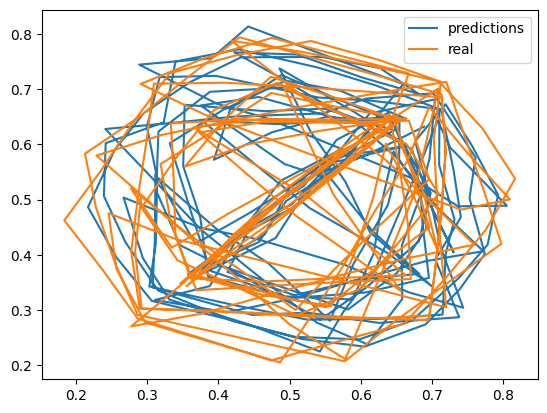

In [710]:
plt.plot(df['model_x_hist'], df['model_y_hist'], label = 'predictions')
plt.plot(df['x_hist'], df['y_hist'], label = 'real')
# plt.plot(df['vlp_x_hist'], df['vlp_y_hist'])


plt.legend()

model mean err:  0.029510210578045117
vlp mean err:  0.031191606988278005
encoder mean err:  0.21324921760585835


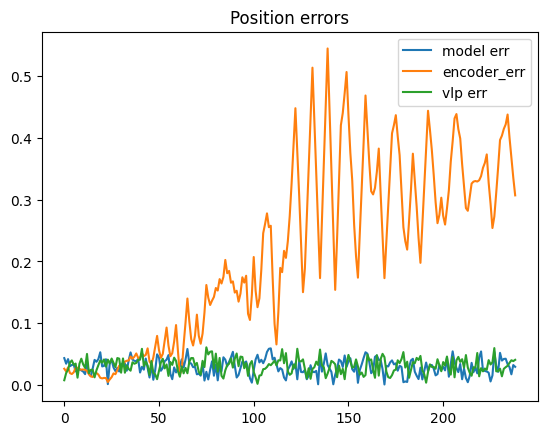

In [711]:
plt.plot(model_pos_errs, label = 'model err')
plt.plot(encoder_pos_errs, label = 'encoder_err')

plt.plot(vlp_pos_errs, label = 'vlp err')
plt.legend()
plt.title('Position errors')
print('model mean err: ', np.mean(model_pos_errs))
print('vlp mean err: ', np.mean(vlp_pos_errs))
print('encoder mean err: ', np.mean(encoder_pos_errs))

mod_heading_err :  9.507916189325393
enc_heading_err:  29.10712317407684
vlp_heading_err:  9.073501744213436


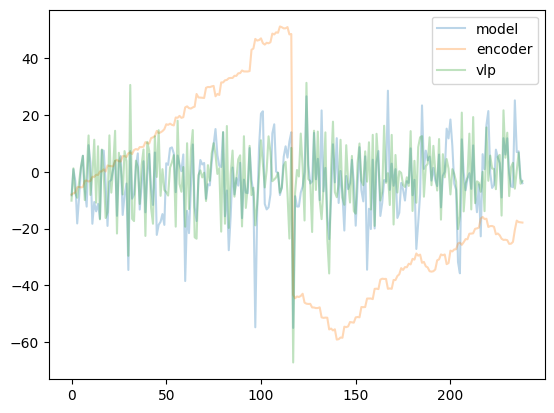

In [705]:
plt.plot(model_heading_err, label = 'model', alpha = 0.3)
plt.plot(encoder_heading_err, label = 'encoder', alpha = 0.3)
plt.plot(vlp_heading_err, label = 'vlp', alpha = 0.3)
plt.legend()

print('mod_heading_err : ', np.mean(np.abs(model_heading_err )))
print('enc_heading_err: ', np.mean(np.abs(encoder_heading_err)))
print('vlp_heading_err: ', np.mean(np.abs(vlp_heading_err)))

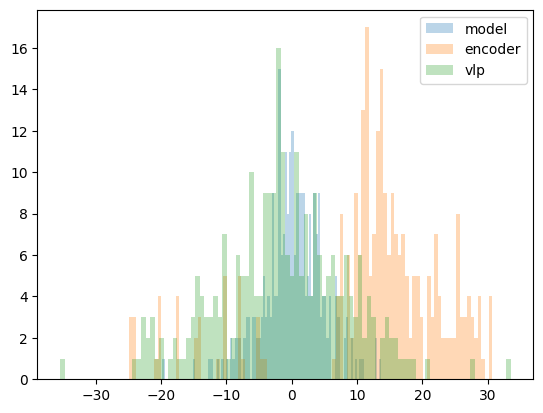

In [674]:
_ = plt.hist(model_heading_err, alpha = 0.3, bins = 100, label = 'model')
_ = plt.hist(encoder_heading_err, alpha = 0.3, bins = 100, label = 'encoder')
_ = plt.hist(vlp_heading_err, alpha = 0.3, bins = 100, label = 'vlp')
plt.legend()